# Feature Analysis

This notebook analyzes the features used in our batter and pitcher models:
- Current feature sets
- Correlation structure
- Feature importance (SHAP)
- Why these features were selected

In [1]:
import os
os.chdir('/Users/matthewgillies/mlb-fantasy-2026')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print(f"Working directory: {os.getcwd()}")

Working directory: /Users/matthewgillies/mlb-fantasy-2026


/Applications/miniconda3/envs/pitchml/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Models and Data

In [2]:
# Load saved models
batter_model_data = joblib.load('models/batter_model.joblib')
pitcher_model_data = joblib.load('models/pitcher_model.joblib')

batter_model = batter_model_data['model']
pitcher_model = pitcher_model_data['model']

batter_features = batter_model_data['feature_cols']
pitcher_features = pitcher_model_data['feature_cols']

print(f"Batter model: {len(batter_features)} features")
print(f"Pitcher model: {len(pitcher_features)} features")

Batter model: 34 features
Pitcher model: 24 features


In [3]:
# Load training data
batters_df = pd.read_csv('data/processed/batters_processed.csv')
pitchers_df = pd.read_csv('data/processed/pitchers_processed.csv')

# Filter to training years (exclude 2025 validation)
batters_train = batters_df[batters_df['Season'].between(2022, 2024)].copy()
pitchers_train = pitchers_df[pitchers_df['Season'].between(2022, 2024)].copy()

print(f"Batter training rows: {len(batters_train)}")
print(f"Pitcher training rows: {len(pitchers_train)}")

Batter training rows: 1125
Pitcher training rows: 1284


## 1.5 Feature Selection Process

Features were selected from a larger candidate pool using:
1. **Hierarchical clustering** based on correlation distance
2. **Representative selection** - choosing the feature with highest target correlation from each cluster

This reduces multicollinearity while retaining predictive power.

In [4]:
# Load ALL available features (before selection)
# These are the lag1 features available in the processed data

all_batter_lag1 = [c for c in batters_train.columns if '_lag1' in c and not c.startswith('Fpoints')]
all_pitcher_lag1 = [c for c in pitchers_train.columns if '_lag1' in c and not c.startswith('Fpoints')]

print(f"Available batter lag1 features: {len(all_batter_lag1)}")
print(f"Available pitcher lag1 features: {len(all_pitcher_lag1)}")
print(f"\nSelected batter features: {len([f for f in batter_features if '_lag1' in f])}")
print(f"Selected pitcher features: {len([f for f in pitcher_features if '_lag1' in f])}")

Available batter lag1 features: 17
Available pitcher lag1 features: 12

Selected batter features: 17
Selected pitcher features: 12


In [5]:
def cluster_and_select(df, features, target_col, threshold=0.3):
    """
    Cluster features based on correlation and select representatives.
    
    Args:
        df: DataFrame with features and target
        features: List of feature column names
        target_col: Target variable name
        threshold: Distance threshold for clustering (1 - |corr|)
    
    Returns:
        cluster_df: DataFrame with cluster assignments
        representatives: Dict of cluster -> best feature
        linkage_matrix: For plotting dendrogram
    """
    from scipy.cluster.hierarchy import linkage, fcluster
    from scipy.spatial.distance import squareform
    
    # Filter to available features
    available = [f for f in features if f in df.columns]
    feature_df = df[available].dropna()
    
    # Correlation matrix
    corr = feature_df.corr()
    
    # Distance = 1 - |correlation|
    dissimilarity = 1 - np.abs(corr)
    np.fill_diagonal(dissimilarity.values, 0)
    
    # Hierarchical clustering
    linkage_matrix = linkage(squareform(dissimilarity), method='average')
    clusters = fcluster(linkage_matrix, threshold, criterion='distance')
    
    cluster_df = pd.DataFrame({
        'Feature': corr.columns,
        'Cluster': clusters
    }).sort_values('Cluster')
    
    # Select representative from each cluster (highest target correlation)
    representatives = {}
    for cluster_id in sorted(cluster_df['Cluster'].unique()):
        cluster_features = cluster_df[cluster_df['Cluster'] == cluster_id]['Feature'].tolist()
        
        # Find feature with highest absolute correlation to target
        target_corrs = {}
        for f in cluster_features:
            if f in df.columns and target_col in df.columns:
                target_corrs[f] = abs(df[f].corr(df[target_col]))
        
        if target_corrs:
            best = max(target_corrs, key=target_corrs.get)
            representatives[cluster_id] = {
                'feature': best,
                'target_corr': target_corrs[best],
                'cluster_size': len(cluster_features),
                'all_features': cluster_features
            }
    
    return cluster_df, representatives, linkage_matrix, corr

### Batter Feature Clustering

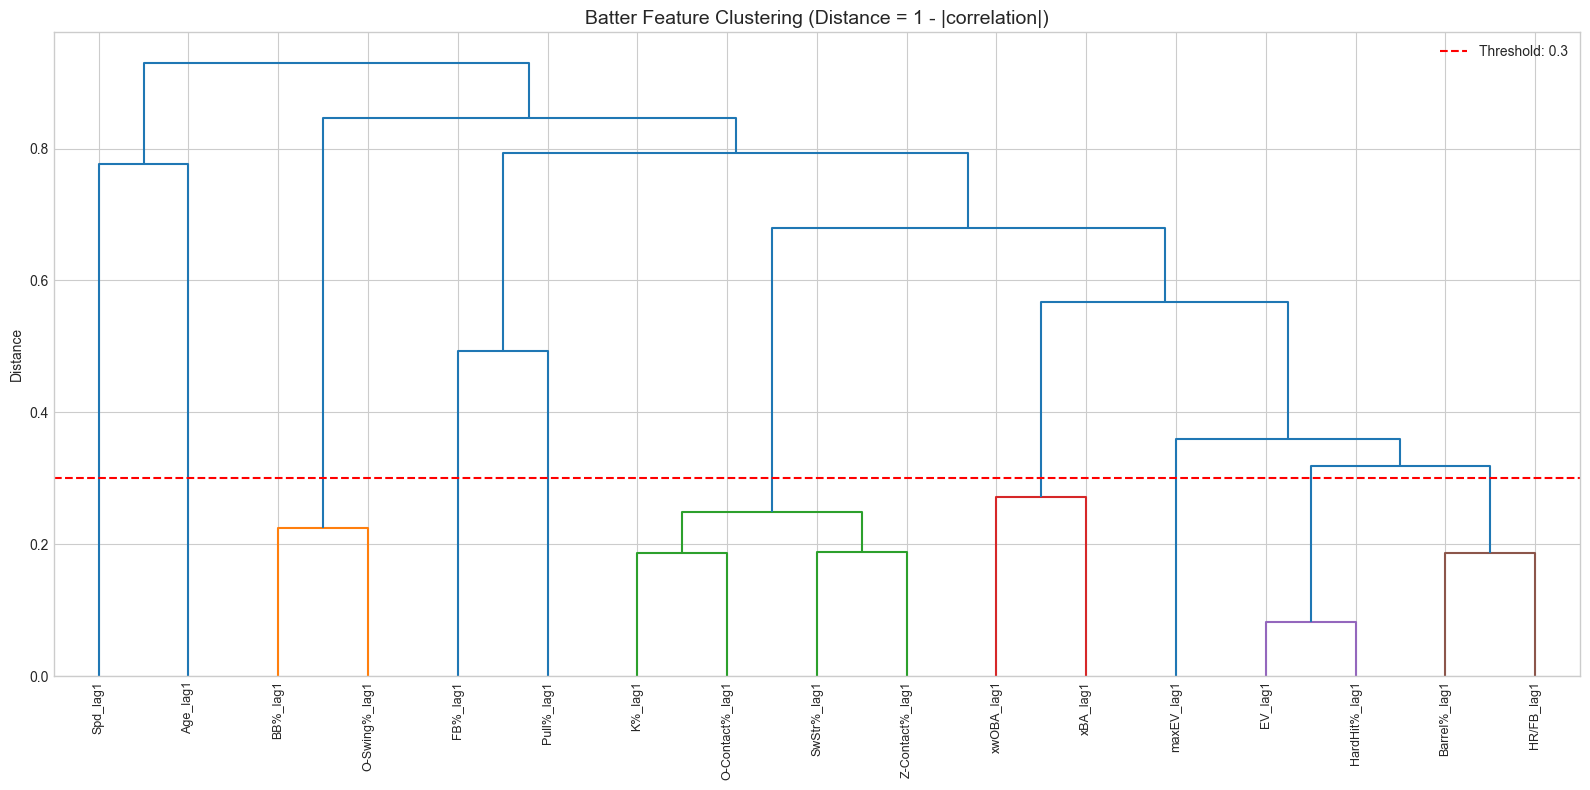

In [6]:
# Cluster batter features
batter_cluster_df, batter_reps, batter_linkage, batter_full_corr = cluster_and_select(
    batters_train, 
    all_batter_lag1, 
    'Fpoints_PA',
    threshold=0.3  # Features with |r| > 0.7 cluster together
)

# Plot dendrogram
from scipy.cluster.hierarchy import dendrogram

fig, ax = plt.subplots(figsize=(16, 8))
dendrogram(
    batter_linkage,
    labels=batter_full_corr.columns.tolist(),
    leaf_rotation=90,
    leaf_font_size=9,
    color_threshold=0.3,
    ax=ax
)
ax.set_title('Batter Feature Clustering (Distance = 1 - |correlation|)', fontsize=14)
ax.set_ylabel('Distance')
ax.axhline(y=0.3, color='r', linestyle='--', label='Threshold: 0.3')
ax.legend()
plt.tight_layout()
plt.savefig('book/_static/images/batter_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Show clusters and selected representatives
print("=== Batter Feature Clusters ===")
print(f"Total clusters: {len(batter_reps)}\n")

for cluster_id, info in sorted(batter_reps.items()):
    selected = info['feature']
    others = [f for f in info['all_features'] if f != selected]
    
    print(f"Cluster {cluster_id}: {info['cluster_size']} features")
    print(f"  SELECTED: {selected} (target corr: {info['target_corr']:.3f})")
    if others:
        print(f"  Dropped:  {', '.join(others[:5])}{'...' if len(others) > 5 else ''}")
    print()

=== Batter Feature Clusters ===
Total clusters: 10

Cluster 1: 1 features
  SELECTED: Spd_lag1 (target corr: 0.118)

Cluster 2: 1 features
  SELECTED: Age_lag1 (target corr: 0.090)

Cluster 3: 2 features
  SELECTED: BB%_lag1 (target corr: 0.156)
  Dropped:  O-Swing%_lag1

Cluster 4: 1 features
  SELECTED: FB%_lag1 (target corr: 0.033)

Cluster 5: 1 features
  SELECTED: Pull%_lag1 (target corr: 0.016)

Cluster 6: 4 features
  SELECTED: K%_lag1 (target corr: 0.318)
  Dropped:  Z-Contact%_lag1, O-Contact%_lag1, SwStr%_lag1

Cluster 7: 2 features
  SELECTED: xwOBA_lag1 (target corr: 0.415)
  Dropped:  xBA_lag1

Cluster 8: 2 features
  SELECTED: EV_lag1 (target corr: 0.258)
  Dropped:  HardHit%_lag1

Cluster 9: 2 features
  SELECTED: Barrel%_lag1 (target corr: 0.158)
  Dropped:  HR/FB_lag1

Cluster 10: 1 features
  SELECTED: maxEV_lag1 (target corr: 0.247)



### Pitcher Feature Clustering

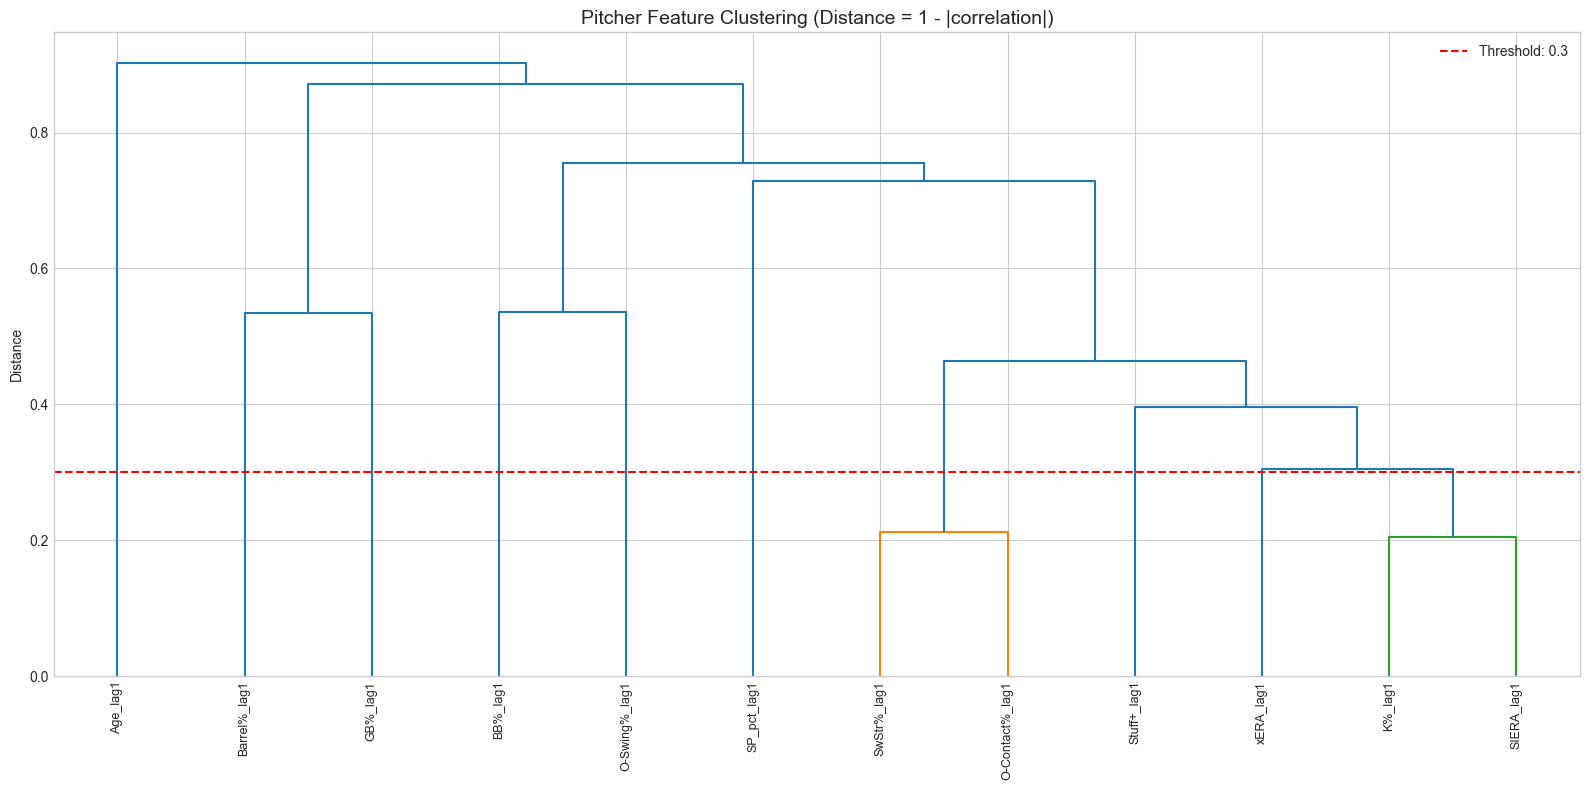

In [8]:
# Cluster pitcher features
pitcher_cluster_df, pitcher_reps, pitcher_linkage, pitcher_full_corr = cluster_and_select(
    pitchers_train, 
    all_pitcher_lag1, 
    'Fpoints_IP',
    threshold=0.3
)

# Plot dendrogram
fig, ax = plt.subplots(figsize=(16, 8))
dendrogram(
    pitcher_linkage,
    labels=pitcher_full_corr.columns.tolist(),
    leaf_rotation=90,
    leaf_font_size=9,
    color_threshold=0.3,
    ax=ax
)
ax.set_title('Pitcher Feature Clustering (Distance = 1 - |correlation|)', fontsize=14)
ax.set_ylabel('Distance')
ax.axhline(y=0.3, color='r', linestyle='--', label='Threshold: 0.3')
ax.legend()
plt.tight_layout()
plt.savefig('book/_static/images/pitcher_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Show pitcher clusters and selected representatives
print("=== Pitcher Feature Clusters ===")
print(f"Total clusters: {len(pitcher_reps)}\n")

for cluster_id, info in sorted(pitcher_reps.items()):
    selected = info['feature']
    others = [f for f in info['all_features'] if f != selected]
    
    print(f"Cluster {cluster_id}: {info['cluster_size']} features")
    print(f"  SELECTED: {selected} (target corr: {info['target_corr']:.3f})")
    if others:
        print(f"  Dropped:  {', '.join(others[:5])}{'...' if len(others) > 5 else ''}")
    print()

=== Pitcher Feature Clusters ===
Total clusters: 10

Cluster 1: 1 features
  SELECTED: Barrel%_lag1 (target corr: 0.103)

Cluster 2: 1 features
  SELECTED: GB%_lag1 (target corr: 0.072)

Cluster 3: 1 features
  SELECTED: BB%_lag1 (target corr: 0.047)

Cluster 4: 1 features
  SELECTED: O-Swing%_lag1 (target corr: 0.149)

Cluster 5: 2 features
  SELECTED: SwStr%_lag1 (target corr: 0.399)
  Dropped:  O-Contact%_lag1

Cluster 6: 2 features
  SELECTED: K%_lag1 (target corr: 0.462)
  Dropped:  SIERA_lag1

Cluster 7: 1 features
  SELECTED: xERA_lag1 (target corr: 0.320)

Cluster 8: 1 features
  SELECTED: Stuff+_lag1 (target corr: 0.424)

Cluster 9: 1 features
  SELECTED: SP_pct_lag1 (target corr: 0.173)

Cluster 10: 1 features
  SELECTED: Age_lag1 (target corr: 0.006)



### Summary: Feature Selection Rationale

The clustering reveals natural groupings of correlated features:

**Batters:**
- Expected stats (xwOBA, xBA, xSLG) → Keep **xwOBA** (most comprehensive)
- Contact quality (EV, HardHit%, Barrel%) → Keep **Barrel%** (most predictive of power)
- Strikeout metrics (K%, SwStr%, Contact%) → Keep **K%** (direct fantasy impact)

**Pitchers:**
- ERA estimators (xERA, SIERA, FIP, xFIP) → Keep **SIERA** (most predictive)
- Strikeout metrics (K%, K/9, SwStr%) → Keep **K%** (direct fantasy scoring)
- Velocity features (removed in favor of **Stuff+** composite)

By selecting one representative per cluster, we maintain predictive power while avoiding multicollinearity issues that can destabilize model coefficients.

---
# Part 1: Batter Features
---

## 2. Batter Feature List

Features are organized into **level** (lag1) and **trend** (lag1 - lag2) components.

In [10]:
# Display batter features by category
lag1_features = [f for f in batter_features if '_lag1' in f]
trend_features = [f for f in batter_features if '_trend' in f]
other_features = [f for f in batter_features if '_lag1' not in f and '_trend' not in f]

print("=== BATTER FEATURES ===")
print(f"\nLevel Features (lag1): {len(lag1_features)}")
for f in lag1_features:
    base = f.replace('_lag1', '')
    print(f"  - {base}")

print(f"\nTrend Features: {len(trend_features)}")
print("  (Same metrics as above, but year-over-year change)")

print(f"\nOther: {other_features}")

=== BATTER FEATURES ===

Level Features (lag1): 17
  - xwOBA
  - xBA
  - EV
  - maxEV
  - Barrel%
  - HardHit%
  - K%
  - BB%
  - SwStr%
  - O-Contact%
  - Z-Contact%
  - O-Swing%
  - FB%
  - HR/FB
  - Pull%
  - Spd
  - Age

Trend Features: 17
  (Same metrics as above, but year-over-year change)

Other: []


### Feature Categories

| Category | Features | Description |
|----------|----------|-------------|
| **Contact Quality** | xwOBA, xBA, EV, maxEV, Barrel%, HardHit% | Expected stats and batted ball quality |
| **Plate Discipline** | K%, BB%, SwStr%, O-Contact%, Z-Contact%, O-Swing% | Strikeout/walk rates, contact ability |
| **Batted Ball Profile** | FB%, HR/FB, Pull% | Fly ball and power indicators |
| **Speed** | Spd | Baserunning and range |
| **Demographics** | Age | Age-related regression/improvement |

## 3. Batter Feature Correlation

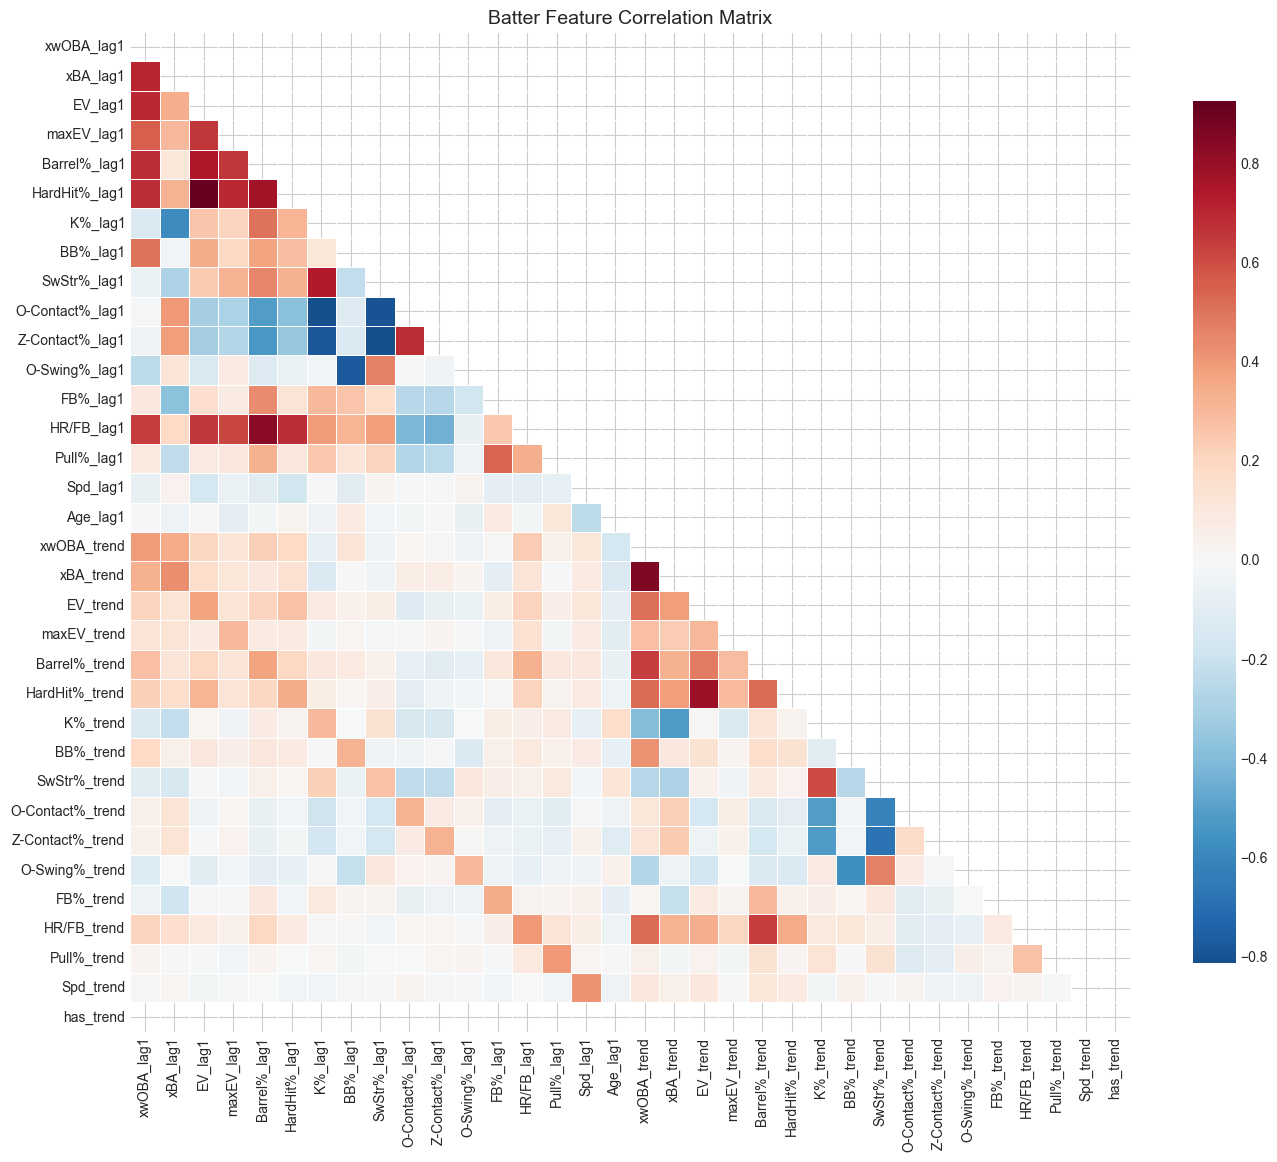

In [11]:
# Get available features in training data
available_batter_features = [f for f in batter_features if f in batters_train.columns]
batter_feature_df = batters_train[available_batter_features].dropna()

# Correlation matrix
batter_corr = batter_feature_df.corr()

# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(batter_corr, dtype=bool))
sns.heatmap(batter_corr, mask=mask, cmap='RdBu_r', center=0, 
            square=True, linewidths=0.5, annot=False,
            cbar_kws={'shrink': 0.8})
plt.title('Batter Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('book/_static/images/batter_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Find highly correlated pairs (|r| > 0.7)
high_corr_pairs = []
for i in range(len(batter_corr.columns)):
    for j in range(i+1, len(batter_corr.columns)):
        if abs(batter_corr.iloc[i, j]) > 0.7:
            high_corr_pairs.append({
                'Feature 1': batter_corr.columns[i],
                'Feature 2': batter_corr.columns[j],
                'Correlation': batter_corr.iloc[i, j]
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', key=abs, ascending=False)
print(f"Highly correlated pairs (|r| > 0.7): {len(high_corr_df)}")
print(high_corr_df.to_string(index=False))

Highly correlated pairs (|r| > 0.7): 13
   Feature 1       Feature 2  Correlation
     EV_lag1   HardHit%_lag1     0.925149
 xwOBA_trend       xBA_trend     0.851601
Barrel%_lag1      HR/FB_lag1     0.835348
     K%_lag1 O-Contact%_lag1    -0.813838
 SwStr%_lag1 Z-Contact%_lag1    -0.810072
 SwStr%_lag1 O-Contact%_lag1    -0.799885
    EV_trend  HardHit%_trend     0.786942
     K%_lag1 Z-Contact%_lag1    -0.781535
    BB%_lag1   O-Swing%_lag1    -0.777005
Barrel%_lag1   HardHit%_lag1     0.774456
     EV_lag1    Barrel%_lag1     0.745325
     K%_lag1     SwStr%_lag1     0.728540
  xwOBA_lag1        xBA_lag1     0.705389


## 4. Batter Feature Importance (SHAP)

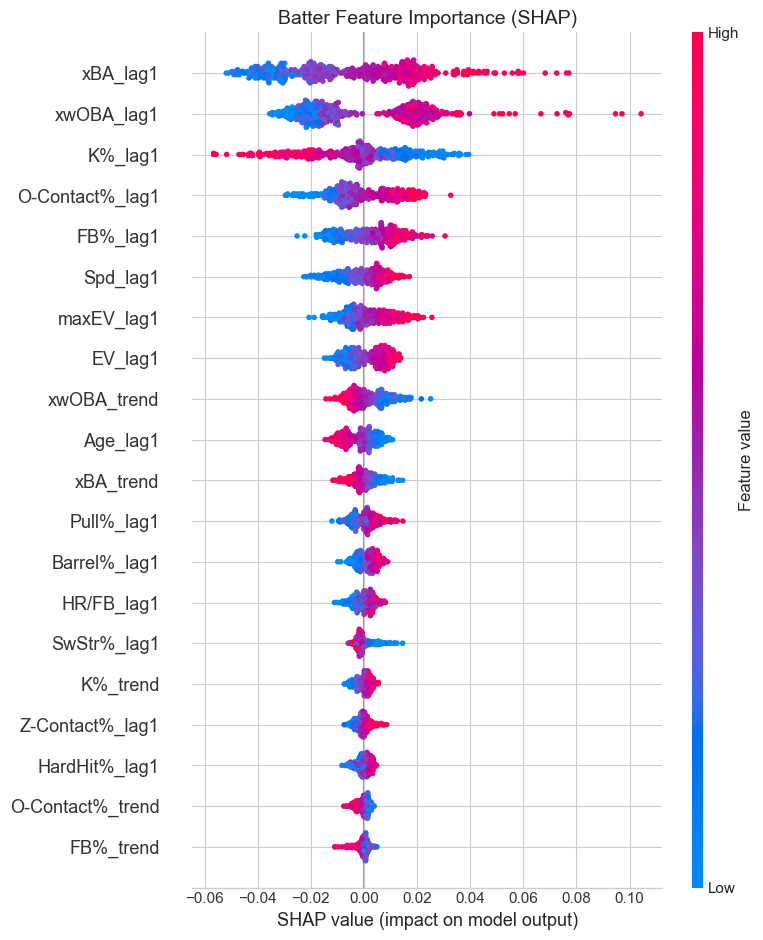

In [13]:
# Prepare data for SHAP
X_batter = batter_feature_df[available_batter_features]

# Fill any remaining NaN with medians
X_batter = X_batter.fillna(X_batter.median())

# Sample for faster computation
X_sample = X_batter.sample(min(500, len(X_batter)), random_state=42)

# SHAP explainer
explainer = shap.TreeExplainer(batter_model)
shap_values = explainer.shap_values(X_sample)

# Summary plot
plt.figure(figsize=(10, 10))
shap.summary_plot(shap_values, X_sample, show=False, max_display=20)
plt.title('Batter Feature Importance (SHAP)', fontsize=14)
plt.tight_layout()
plt.savefig('book/_static/images/batter_shap.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Mean absolute SHAP values
mean_shap = pd.DataFrame({
    'Feature': X_sample.columns,
    'Mean |SHAP|': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=False)

print("=== Batter Feature Importance ===")
print(mean_shap.to_string(index=False))

=== Batter Feature Importance ===
         Feature  Mean |SHAP|
        xBA_lag1     0.021995
      xwOBA_lag1     0.020767
         K%_lag1     0.014786
 O-Contact%_lag1     0.010166
        FB%_lag1     0.008759
        Spd_lag1     0.006636
      maxEV_lag1     0.006541
         EV_lag1     0.006246
     xwOBA_trend     0.005237
        Age_lag1     0.004874
       xBA_trend     0.003419
      Pull%_lag1     0.003299
    Barrel%_lag1     0.002930
      HR/FB_lag1     0.002650
     SwStr%_lag1     0.002163
        K%_trend     0.001962
 Z-Contact%_lag1     0.001771
   HardHit%_lag1     0.001750
O-Contact%_trend     0.001506
       FB%_trend     0.001241
     Pull%_trend     0.001173
  HardHit%_trend     0.001039
        EV_trend     0.000873
    SwStr%_trend     0.000839
     maxEV_trend     0.000799
        BB%_lag1     0.000768
       BB%_trend     0.000741
   O-Swing%_lag1     0.000708
     HR/FB_trend     0.000697
       Spd_trend     0.000665
   Barrel%_trend     0.000627
Z-Cont

---
# Part 2: Pitcher Features
---

## 5. Pitcher Feature List

In [15]:
# Display pitcher features by category
lag1_pit = [f for f in pitcher_features if '_lag1' in f]
trend_pit = [f for f in pitcher_features if '_trend' in f]
other_pit = [f for f in pitcher_features if '_lag1' not in f and '_trend' not in f]

print("=== PITCHER FEATURES ===")
print(f"\nLevel Features (lag1): {len(lag1_pit)}")
for f in lag1_pit:
    base = f.replace('_lag1', '')
    print(f"  - {base}")

print(f"\nTrend Features: {len(trend_pit)}")
print("  (Same metrics as above, but year-over-year change)")

print(f"\nOther: {other_pit}")

=== PITCHER FEATURES ===

Level Features (lag1): 12
  - K%
  - BB%
  - SwStr%
  - O-Swing%
  - O-Contact%
  - xERA
  - SIERA
  - Barrel%
  - GB%
  - Stuff+
  - Age
  - SP_pct

Trend Features: 12
  (Same metrics as above, but year-over-year change)

Other: []


### Pitcher Feature Categories

| Category | Features | Description |
|----------|----------|-------------|
| **Strikeout/Walk** | K%, BB% | Core skill indicators |
| **Swing & Miss** | SwStr%, O-Swing%, O-Contact% | Ability to generate whiffs |
| **ERA Estimators** | xERA, SIERA | Predictive ERA metrics |
| **Batted Ball** | Barrel%, GB% | Quality of contact allowed |
| **Pitch Quality** | Stuff+ | Composite pitch quality metric |
| **Role** | SP_pct | Starter vs reliever usage |
| **Demographics** | Age | Age-related changes |

## 6. Pitcher Feature Correlation

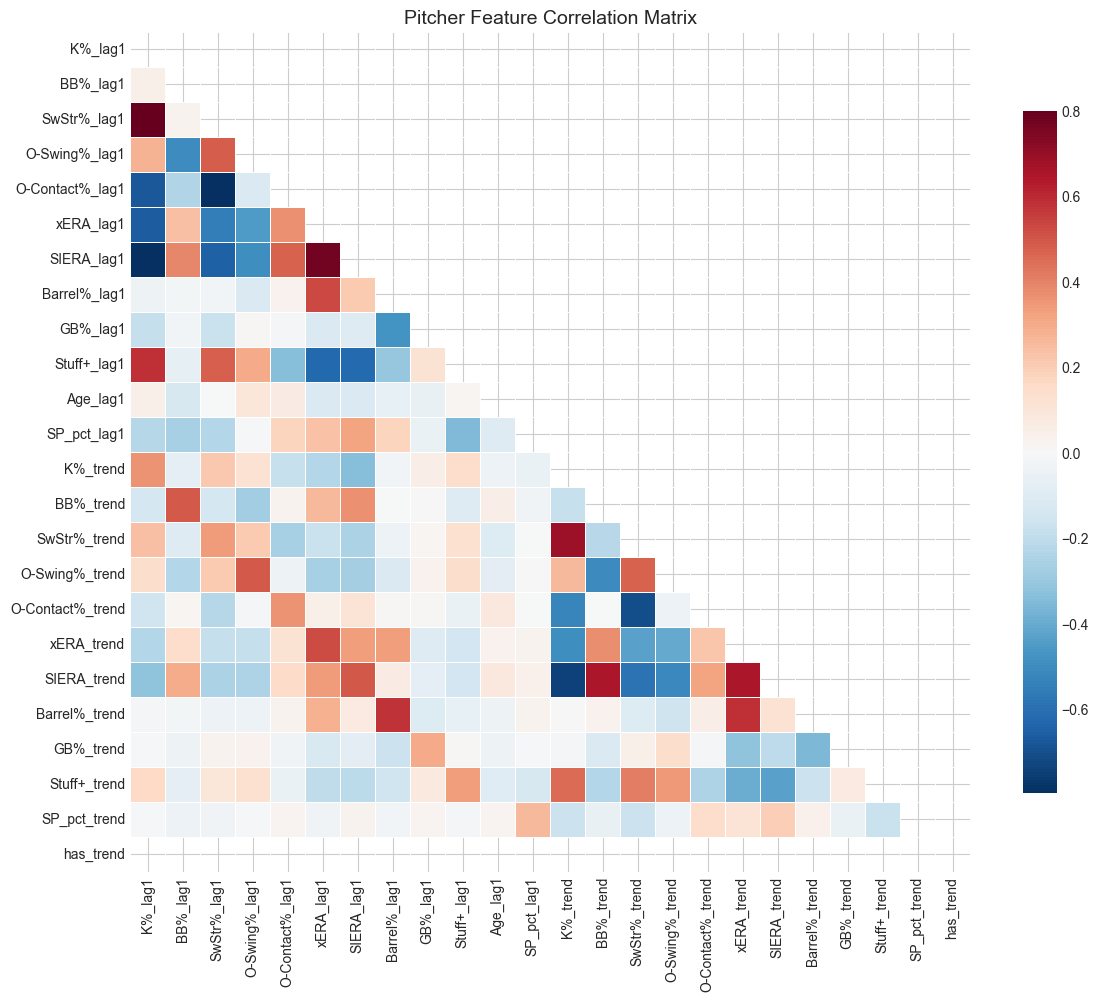

In [16]:
# Get available features in training data
available_pitcher_features = [f for f in pitcher_features if f in pitchers_train.columns]
pitcher_feature_df = pitchers_train[available_pitcher_features].dropna()

# Correlation matrix
pitcher_corr = pitcher_feature_df.corr()

# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(pitcher_corr, dtype=bool))
sns.heatmap(pitcher_corr, mask=mask, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, annot=False,
            cbar_kws={'shrink': 0.8})
plt.title('Pitcher Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('book/_static/images/pitcher_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Find highly correlated pairs for pitchers
high_corr_pit = []
for i in range(len(pitcher_corr.columns)):
    for j in range(i+1, len(pitcher_corr.columns)):
        if abs(pitcher_corr.iloc[i, j]) > 0.7:
            high_corr_pit.append({
                'Feature 1': pitcher_corr.columns[i],
                'Feature 2': pitcher_corr.columns[j],
                'Correlation': pitcher_corr.iloc[i, j]
            })

high_corr_pit_df = pd.DataFrame(high_corr_pit).sort_values('Correlation', key=abs, ascending=False)
print(f"Highly correlated pairs (|r| > 0.7): {len(high_corr_pit_df)}")
print(high_corr_pit_df.to_string(index=False))

Highly correlated pairs (|r| > 0.7): 6
   Feature 1        Feature 2  Correlation
     K%_lag1      SwStr%_lag1     0.800897
 SwStr%_lag1  O-Contact%_lag1    -0.796594
     K%_lag1       SIERA_lag1    -0.792794
   xERA_lag1       SIERA_lag1     0.774772
    K%_trend      SIERA_trend    -0.742420
SwStr%_trend O-Contact%_trend    -0.707696


## 7. Pitcher Feature Importance (SHAP)

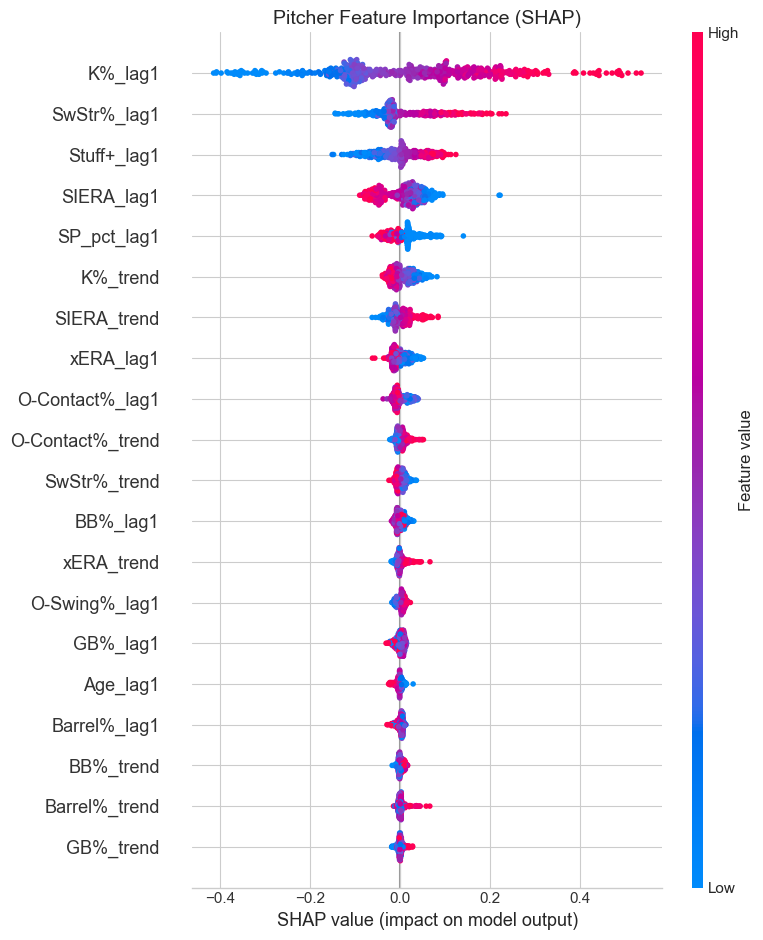

In [18]:
# Prepare data for SHAP
X_pitcher = pitcher_feature_df[available_pitcher_features]
X_pitcher = X_pitcher.fillna(X_pitcher.median())

# Sample for faster computation
X_pit_sample = X_pitcher.sample(min(500, len(X_pitcher)), random_state=42)

# SHAP explainer
pit_explainer = shap.TreeExplainer(pitcher_model)
pit_shap_values = pit_explainer.shap_values(X_pit_sample)

# Summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(pit_shap_values, X_pit_sample, show=False, max_display=20)
plt.title('Pitcher Feature Importance (SHAP)', fontsize=14)
plt.tight_layout()
plt.savefig('book/_static/images/pitcher_shap.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# Mean absolute SHAP values for pitchers
mean_shap_pit = pd.DataFrame({
    'Feature': X_pit_sample.columns,
    'Mean |SHAP|': np.abs(pit_shap_values).mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=False)

print("=== Pitcher Feature Importance ===")
print(mean_shap_pit.to_string(index=False))

=== Pitcher Feature Importance ===
         Feature  Mean |SHAP|
         K%_lag1     0.156340
     SwStr%_lag1     0.053123
     Stuff+_lag1     0.042122
      SIERA_lag1     0.039696
     SP_pct_lag1     0.024325
        K%_trend     0.020813
     SIERA_trend     0.018854
       xERA_lag1     0.014206
 O-Contact%_lag1     0.012260
O-Contact%_trend     0.007689
    SwStr%_trend     0.007315
        BB%_lag1     0.007254
      xERA_trend     0.006683
   O-Swing%_lag1     0.006144
        GB%_lag1     0.006101
        Age_lag1     0.005100
    Barrel%_lag1     0.004723
       BB%_trend     0.004223
   Barrel%_trend     0.004025
       GB%_trend     0.003812
    SP_pct_trend     0.003435
  O-Swing%_trend     0.003195
    Stuff+_trend     0.001732
       has_trend     0.000595


---
## Summary
---

### Batter Model (34 features)
- **17 level features** (prior season metrics)
- **16 trend features** (year-over-year change)
- **1 indicator** (`has_trend` - whether trend data is real or imputed)

### Pitcher Model (24 features)  
- **12 level features** (prior season metrics)
- **11 trend features** (year-over-year change)
- **1 indicator** (`has_trend`)

### Key Design Decisions
1. **Rate stats over counting stats** - More predictive, less playing time dependent
2. **Level + Trend framework** - Captures both current ability and trajectory
3. **Stuff+ over arsenal features** - Single composite metric avoids multicollinearity
4. **No W/L/SV/HLD for pitchers** - Too team/luck dependent, added from projections later